In [20]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
pip install tensorflow

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import numpy as np
import os

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

traindataset = train_datagen.flow_from_directory("/content/drive/MyDrive/brain tumor prediction/training" , target_size=(200,200), batch_size=8, class_mode='categorical')

Found 5712 images belonging to 4 classes.


In [5]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [6]:


validationdata = test_datagen.flow_from_directory("/content/drive/MyDrive/brain tumor prediction/testing " ,target_size=(200,200),batch_size=8,class_mode='categorical')

Found 1311 images belonging to 4 classes.


In [7]:
print(traindataset.class_indices)

{' meningioma': 0, 'glioma ': 1, 'notumor': 2, 'pituitary': 3}


In [8]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), padding ='same', activation='relu', input_shape=(200,200,3)),
    tf.keras.layers.MaxPool2D(2,2),
    tf.keras.layers.Conv2D(32, (3,3),  padding ='same', activation='relu'),
    tf.keras.layers.MaxPool2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3),  padding ='same', activation='relu'),
    tf.keras.layers.MaxPool2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(4, activation='softmax') # Changed from 5 to 4
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()
num_train_samples = len(traindataset)
batch_size = 50
steps_per_epoch = 50
tf.config.run_functions_eagerly(True)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 40000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    20,480,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,506,148 (78.22 MB)

 Trainable params: 20,506,148 (78.22 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(traindataset, validation_data=validationdata, epochs=5)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


714/714 ━━━━━━━━━━━━━━━━━━━━ 1879s 3s/step - accuracy: 0.7971 - loss: 0.5189 - val_accuracy: 0.5843 - val_loss: 2.1191
Epoch 2/5
714/714 ━━━━━━━━━━━━━━━━━━━━ 866s 1s/step - accuracy: 0.9310 - loss: 0.1884 - val_accuracy: 0.5843 - val_loss: 3.5208
Epoch 3/5
714/714 ━━━━━━━━━━━━━━━━━━━━ 848s 1s/step - accuracy: 0.9599 - loss: 0.1142 - val_accuracy: 0.5622 - val_loss: 2.7975
Epoch 4/5
714/714 ━━━━━━━━━━━━━━━━━━━━ 849s 1s/step - accuracy: 0.9809 - loss: 0.0617 - val_accuracy: 0.5629 - val_loss: 3.6242
Epoch 5/5
714/714 ━━━━━━━━━━━━━━━━━━━━ 854s 1s/step - accuracy: 0.9800 - loss: 0.0548 - val_accuracy: 0.5728 - val_loss: 4.5153


In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
model.save('/content/drive/MyDrive/brain_tumor_model/model.h5')

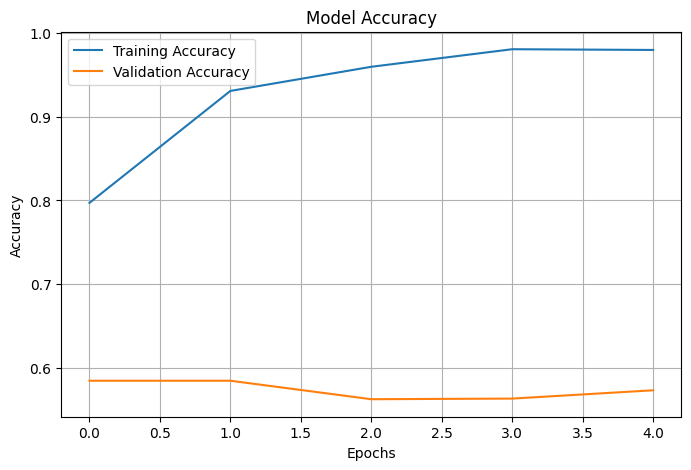

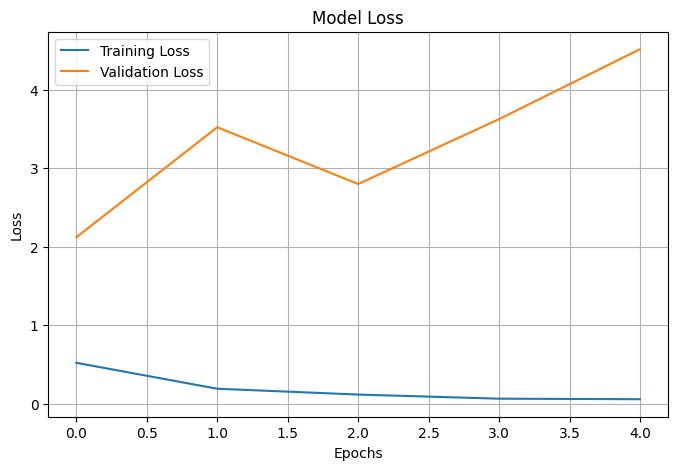

In [12]:
import matplotlib.pyplot as plt

# ---- Accuracy Graph ----
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# ---- Loss Graph ----
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


In [23]:
from google.colab import files
uploaded = files.upload()


Saving Te-gl_0014.jpg to Te-gl_0014.jpg


✅ Using latest uploaded image: /content/Te-gl_0014.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


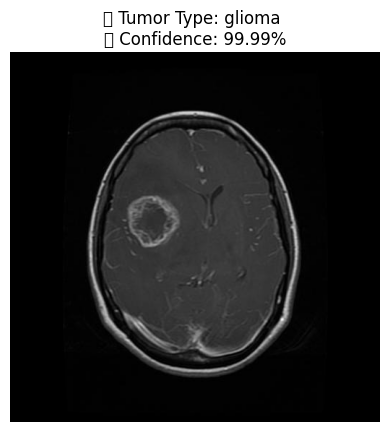

In [24]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Load your trained model
from tensorflow.keras.models import load_model
model = load_model("/content/drive/MyDrive/brain_tumor_model/model.h5")   # Corrected path to the saved model

# Update this with your uploaded image filename
import os

# Automatically detect the latest uploaded image in /content
folder_path = "/content"
image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

if image_files:
    img_path = os.path.join(folder_path, max(image_files, key=lambda x: os.path.getmtime(os.path.join(folder_path, x))))
    print(f"✅ Using latest uploaded image: {img_path}")
else:
    print("❌ No image found. Please upload a .jpg, .jpeg, or .png file.")


# Load and preprocess the image
img = image.load_img(img_path, target_size=(200, 200))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# Predict
pred = model.predict(img_array)
predicted_class_index = np.argmax(pred)

# Class labels (update these as per your dataset)
# Class labels (exact order from traindataset.class_indices)
class_labels = [" meningioma", "glioma ", "notumor", "pituitary"]

predicted_class = class_labels[predicted_class_index]
confidence = np.max(pred) * 100

# Display result
plt.imshow(image.load_img(img_path))
plt.title(f"🧠 Tumor Type: {predicted_class}\n🎯 Confidence: {confidence:.2f}%")
plt.axis("off")
plt.show()

In [25]:
print(traindataset.class_indices)

{' meningioma': 0, 'glioma ': 1, 'notumor': 2, 'pituitary': 3}


/tmp/ipykernel_2381/1136384098.py:21: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


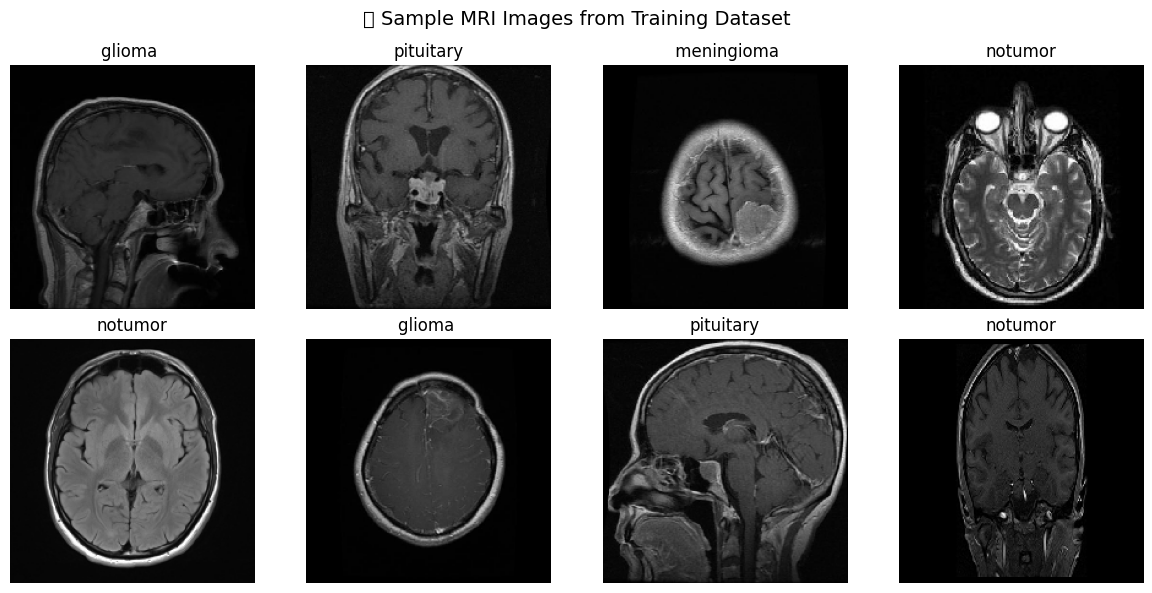

In [26]:
# ----------------------------------------------------
# 📊 DATASET VISUALIZATION
# ----------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Show some sample images from the training dataset
images, labels = next(iter(traindataset))  # Take one batch from training data

plt.figure(figsize=(12, 6))
for i in range(8):  # Display 8 sample images
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i])
    label_index = np.argmax(labels[i])
    class_name = list(traindataset.class_indices.keys())[label_index]
    plt.title(class_name)
    plt.axis('off')

plt.suptitle("🧠 Sample MRI Images from Training Dataset", fontsize=14)
plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


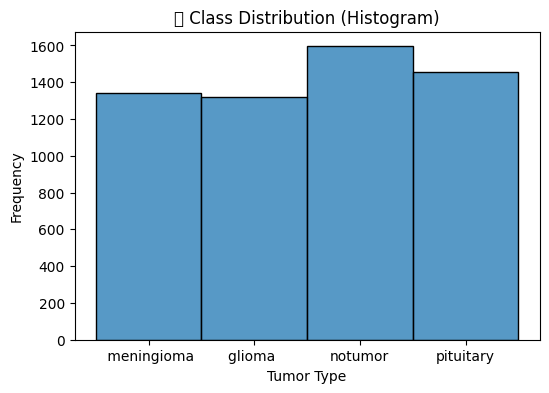

In [17]:
# 📈 CLASS DISTRIBUTION (BAR / HISTOGRAM)
# ----------------------------------------------------
class_counts = traindataset.classes
class_labels = list(traindataset.class_indices.keys())

plt.figure(figsize=(6, 4))
sns.histplot(x=[class_labels[i] for i in class_counts], bins=len(class_labels))
plt.title("📊 Class Distribution (Histogram)")
plt.xlabel("Tumor Type")
plt.ylabel("Frequency")
plt.show()


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


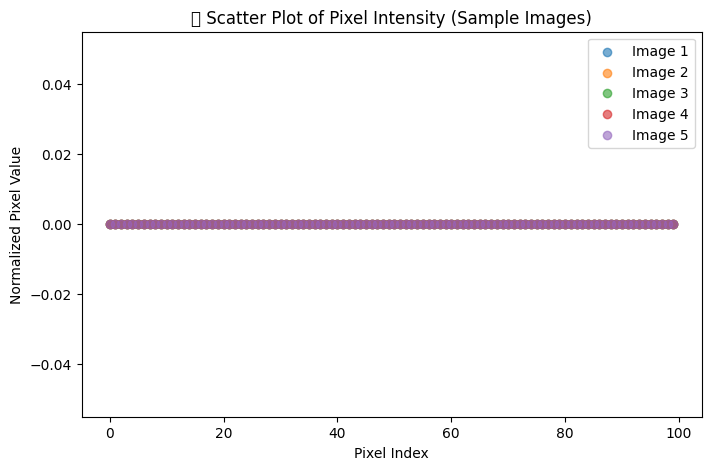

In [18]:
# 🔵 SCATTER PLOT (Random visualization)
# ----------------------------------------------------
# We'll plot random pixel values of first few images as scatter points
# (just for dataset feature visualization)
flattened_images = [img.flatten()[:100] for img in images]  # take 100 pixel values per image
flattened_images = np.array(flattened_images)
x = np.arange(flattened_images.shape[1])

plt.figure(figsize=(8, 5))
for i in range(5):  # Show scatter for 5 images
    plt.scatter(x, flattened_images[i], label=f"Image {i+1}", alpha=0.6)
plt.title("🔵 Scatter Plot of Pixel Intensity (Sample Images)")
plt.xlabel("Pixel Index")
plt.ylabel("Normalized Pixel Value")
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129383 (\N{PIE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


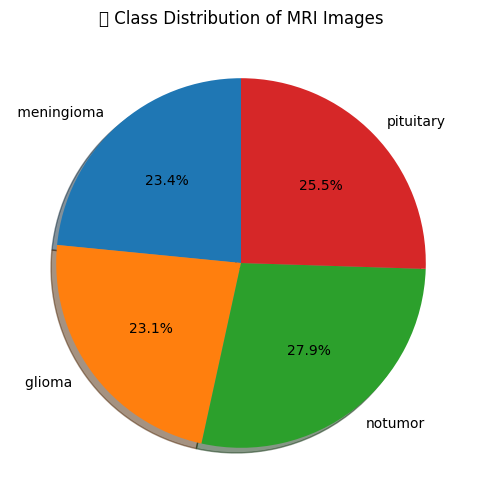

In [19]:
# ----------------------------------------------------
# 🥧 PIE CHART - Class Distribution
# ----------------------------------------------------
class_counts = traindataset.classes
class_labels = list(traindataset.class_indices.keys())

# Count how many images per class
unique, counts = np.unique(class_counts, return_counts=True)

plt.figure(figsize=(6,6))
plt.pie(counts, labels=[class_labels[i] for i in unique],
        autopct='%1.1f%%', startangle=90, shadow=True)
plt.title("🥧 Class Distribution of MRI Images")
plt.show()